#  Pertemuan 3: Linear Regression & Polynomial Regression

**Nama:** Andi Mawadda Taiba 
**NIM:** 105841103623
**Kelas:** 5A Applied Machine Learning
**Tanggal:** 14 Maret - 2026

> Pastikan semua cell sudah dijalankan dan tidak ada error.

# 1. Tujuan Praktikum

Tujuan dari praktikum ini adalah untuk memahami bagaimana model regresi digunakan dalam memprediksi nilai numerik berdasarkan data yang tersedia. Pada praktikum ini mahasiswa mempelajari cara membangun model Linear Regression sederhana, Multiple Linear Regression, serta Polynomial Regression untuk menangkap pola hubungan yang lebih kompleks pada data.

Selain itu, praktikum ini juga bertujuan untuk melatih kemampuan dalam melakukan eksplorasi data, membagi dataset menjadi data latih dan data uji, serta mengevaluasi performa model menggunakan beberapa metrik evaluasi seperti MAE, RMSE, dan R².

> Dengan melakukan percobaan ini diharapkan mahasiswa dapat memahami bagaimana sebuah model machine learning bekerja dalam mempelajari hubungan antara variabel input dan variabel target.

# 2. Dataset yang Digunakan

Dataset yang digunakan pada praktikum ini adalah Student Performance Dataset yang berisi berbagai faktor yang mempengaruhi performa akademik siswa.

Beberapa variabel yang digunakan antara lain:

**Hours_Studied	 :** jumlah jam belajar siswa

**Attendance :** tingkat kehadiran siswa

**Sleep_Hours :** durasi tidur siswa

**Exam_Score :** nilai ujian siswa
> Variabel exam_score digunakan sebagai target yang akan diprediksi oleh model regresi.

# 3. Langkah Kerja

Langkah-langkah yang dilakukan pada praktikum ini adalah sebagai berikut:

- Mengimpor library yang diperlukan untuk pengolahan data dan pembuatan model.
- Memuat dataset ke dalam lingkungan Python menggunakan library Pandas.
- Melakukan eksplorasi data untuk melihat struktur dataset.
- Membuat model Simple Linear Regression menggunakan satu variabel.
- Membuat model Multiple Linear Regression menggunakan beberapa variabel.
- Membangun model Polynomial Regression untuk melihat kemungkinan hubungan non-linear.
- Mengevaluasi performa model menggunakan metrik evaluasi.
- Membandingkan hasil dari masing-masing model regresi.

# IMPORT LIBRARY
**Kode di bawah digunakan untuk memanggil beberapa library yang dibutuhkan dalam praktikum ini.**
- Library Pandas digunakan untuk membaca dan mengelola dataset dalam bentuk tabel.
- Library NumPy membantu dalam melakukan perhitungan numerik. Sementara itu
- Matplotlib digunakan untuk membuat visualisasi data agar hubungan antar variabel dapat terlihat dengan lebih jelas.
- Beberapa modul dari Scikit-Learn juga digunakan untuk membangun model machine learning.
- Modul train_test_split digunakan untuk membagi data menjadi data latih dan data uji, LinearRegression digunakan untuk membangun model regresi,
- PolynomialFeatures digunakan untuk membentuk fitur polynomial.
- Modul evaluasi seperti mean_absolute_error, mean_squared_error, dan r2_score digunakan untuk menilai performa model.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Memuat Dataset
Pada bagian ini dataset dimuat menggunakan fungsi read_csv() dari library Pandas.
- File dataset yang digunakan berupa file CSV yang berisi data performa siswa.

Setelah dataset berhasil dimuat 
- fungsi head() digunakan untuk menampilkan beberapa baris pertama dari dataset.
>Hal ini dilakukan untuk memastikan bahwa data telah terbaca dengan benar serta untuk melihat gambaran awal dari struktur data yang digunakan.

In [32]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Melihat Informasi Dataset
- Fungsi info() menampilkan informasi mengenai jumlah data, nama kolom, serta tipe data dari setiap variabel yang ada dalam dataset. Informasi ini penting untuk mengetahui apakah terdapat data yang kosong atau tipe data yang tidak sesuai.
- Fungsi describe() memberikan ringkasan statistik dari setiap variabel numerik, seperti nilai rata-rata, nilai minimum, nilai maksimum, dan standar deviasi.

In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# Visualisasi Data
Visualisasi ini dibuat untuk melihat hubungan antara jumlah jam belajar dengan nilai ujian siswa. Grafik yang digunakan adalah scatter plot yang menampilkan titik-titik data berdasarkan dua variabel.
- Sumbu horizontal menunjukkan jumlah jam belajar, sedangkan sumbu vertikal menunjukkan nilai ujian. Dengan melihat grafik ini kita dapat memperoleh gambaran apakah terdapat hubungan antara kedua variabel tersebut.
>Jika titik-titik data membentuk pola tertentu, maka hal tersebut dapat menjadi indikasi bahwa terdapat hubungan antara jam belajar dan nilai ujian siswa.

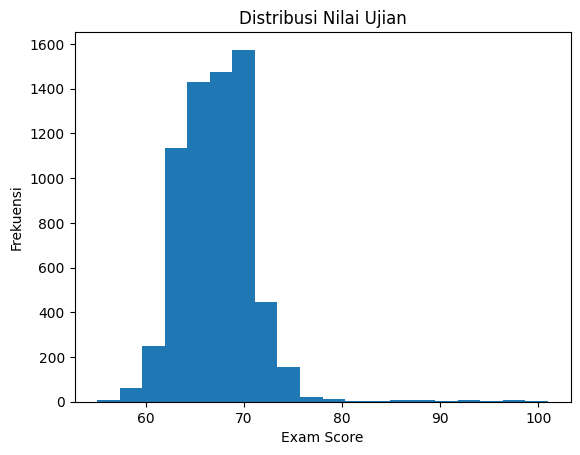

In [15]:
plt.hist(df["Exam_Score"], bins=20)
plt.title("Distribusi Nilai Ujian")
plt.xlabel("Exam Score")
plt.ylabel("Frekuensi")
plt.show()

# Simple Linear Regression
Pada tahap ini dibuat model Linear Regression sederhana dengan menggunakan satu variabel yaitu Hours_Studied sebagai fitur input.

- Variabel fitur berisi kolom jam belajar
- variabel target berisi nilai ujian yang ingin diprediksi.

Dataset kemudian dibagi menjadi data latih (training data) dan data uji (testing data) menggunakan fungsi train_test_split(). Pembagian ini dilakukan agar model dapat dilatih pada sebagian data dan kemudian diuji pada data yang belum pernah dilihat sebelumnya.

Model regresi kemudian dibuat menggunakan LinearRegression() dan dilatih menggunakan metode fit(). Setelah proses pelatihan selesai, model digunakan untuk melakukan prediksi terhadap data uji menggunakan fungsi predict().

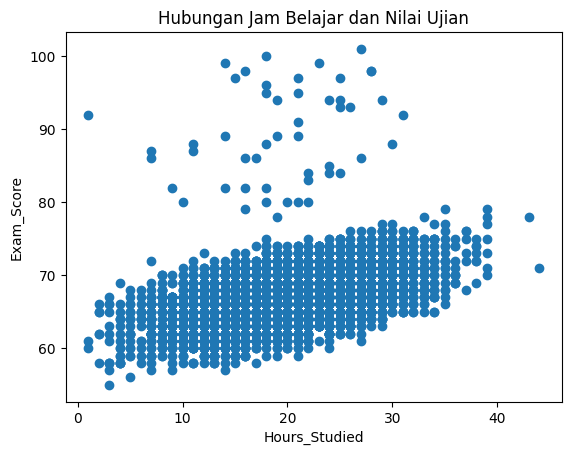

In [20]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.title("Hubungan Jam Belajar dan Nilai Ujian")
plt.show()

# Evaluasi Model
Bagian ini digunakan untuk menilai performa model regresi yang telah dibuat.

- MAE (Mean Absolute Error) menunjukkan rata-rata selisih absolut antara nilai prediksi dan nilai sebenarnya. Semakin kecil nilai MAE maka model semakin baik.
- RMSE (Root Mean Squared Error) mengukur besar kesalahan prediksi dengan memberikan penalti lebih besar terhadap kesalahan yang besar.
- R² (Coefficient of Determination) menunjukkan seberapa baik model mampu menjelaskan variasi data. Nilai R² yang mendekati 1 menunjukkan bahwa model memiliki performa yang baik dalam menjelaskan hubungan antara variabel.

In [23]:
fitur = df[["Hours_Studied"]]
target = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    fitur, target, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

prediksi = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, prediksi)
rmse = np.sqrt(mean_squared_error(y_test, prediksi))
r2 = r2_score(y_test, prediksi)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.4475687452945643
RMSE: 3.294832513010839
R2: 0.2319868674542106


# Visualisasi Hasil Regresi Linear
Grafik ini menunjukkan garis regresi yang menggambarkan hubungan linear antara waktu belajar dan nilai ujian.

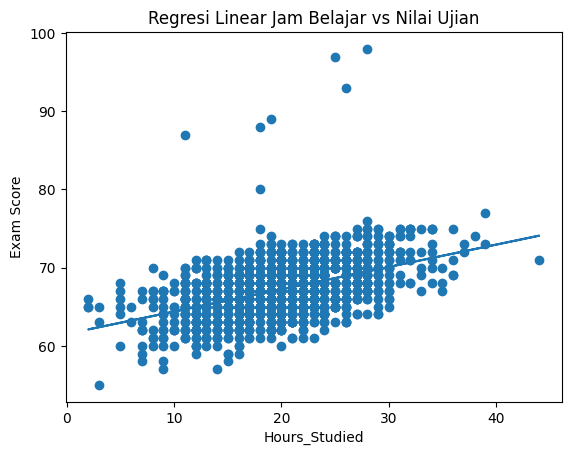

In [26]:
plt.scatter(X_test, y_test)
plt.plot(X_test, prediksi)
plt.xlabel("Hours_Studied")
plt.ylabel("Exam Score")
plt.title("Regresi Linear Jam Belajar vs Nilai Ujian")
plt.show()

# Multiple Linear Regression
Pada tahap ini model regresi dibangun menggunakan lebih dari satu variabel input. Variabel yang digunakan adalah Hours_Studied, Attendance, dan Sleep_H|ours.

Dengan menggunakan beberapa variabel sekaligus, model diharapkan dapat menangkap informasi yang lebih lengkap mengenai faktor-faktor yang mempengaruhi nilai ujian siswa.

Proses pelatihan model dilakukan dengan cara yang sama seperti pada regresi linear sederhana, yaitu dengan membagi data menjadi data latih dan data uji, kemudian melatih model menggunakan fungsi fit().

In [28]:
fitur = df[["Hours_Studied","Attendance","Sleep_Hours"]]
target = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    fitur, target, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

prediksi_multi = model_multi.predict(X_test)

In [29]:
print("MAE:", mean_absolute_error(y_test, prediksi_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediksi_multi)))
print("R2:", r2_score(y_test, prediksi_multi))

MAE: 1.4706300773376364
RMSE: 2.412019889780555
R2: 0.5884110279740732


# Polynomial Regression
Polynomial Regression digunakan ketika hubungan antara variabel tidak sepenuhnya linear. Pada metode ini fitur asli akan diubah menjadi bentuk polynomial, misalnya menjadi pangkat dua atau pangkat tiga.
Dalam contoh ini digunakan degree = 2, yang berarti fitur study_hours akan ditambahkan dengan komponen study_hours². Dengan cara ini model dapat menangkap pola hubungan yang melengkung atau non-linear.
Setelah fitur polynomial dibuat, model regresi linear tetap digunakan untuk melakukan pelatihan dan prediksi.

In [38]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, pred_poly))
r2_poly = r2_score(y_test, pred_poly)

print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2:", r2_poly)

MAE: 2.4447795821288105
RMSE: 3.2931729586684346
R2: 0.23276034442853466
